In [1]:
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torch.nn import functional as F
import numpy as np

import random
from typing import Tuple, List, Optional
import matplotlib.pyplot as plt
from datetime import datetime
import copy


import lightning as pl
from lightning.pytorch.loggers import WandbLogger
import wandb
import pprint

import monai
from monai.losses import DiceLoss, DiceCELoss, SoftclDiceLoss, DiceFocalLoss, NACLLoss
from kornia.losses import total_variation

from Models.model import MLP, initialize_siren_weights, SineLayer, ReLULayer
from Models.model_trainer import ModelTrainerModule



from Models.models import Siren, Finer

from Utils.utils import get_full_img, norm, get_device, dice_stack_helper, get_model, ClearCache
from Data.load_ixi import load_data
from Utils.defaults import default_config
from Utils.plotting_utils2 import plot_seg_results_paper, plot_final_results_paper, plot_hf_results_paper
from Utils.plotting_utils import loss_plot, plot_image_metrics, plot_4_images
from LFSynth.ContrastModulation import ContrastModulation

from Data.patchwise3D import RandomPointsDataset
from onnxruntime import InferenceSession
import onnx

Load data

In [2]:
from LFSynth.HF_ContrastEstimation import forward, load_val_data as load_data 

POINTS_PER_SAMPLE = 96*96*4
lf_points_per_sample = 48*48*4

config = copy.deepcopy(default_config)
config["in_features"] = 3
config["slice"] = 11
config["is_new_contrast"] = False #make this true when using new c vector
config["M"] = [1, 1, 1]
config["points_num"] = 96*96*4
config["downsampled_points"] = 96*96*4
config["hf_chunk_size"] = (96, 96, 4)
config["lf_chunk_size"] =  (96, 96, 4)

dataset_num = '0011'

slice_num = config["slice"]

hf_ground_truth, lf_gt, lf_gt_seg_dice, M = load_data(dataset_num, target_type = 'ulf' , config = config) 
gt_image = torch.tensor(norm(hf_ground_truth)).unsqueeze(-1)
gt_image = gt_image.to(torch.float32)
lf_gt = torch.tensor(norm(lf_gt)).unsqueeze(-1)
lf_gt = lf_gt.to(torch.float32)
# plt.imshow(lf_gt[:,:,slice_num], cmap='gray')
# plt.show()
print("gt_image: ", gt_image.shape, "lf_gt: ", lf_gt.shape, "lf_gt_seg_dice: ", lf_gt_seg_dice.shape)
print('gt_image, lf_gt loaded')

config["size"] = hf_ground_truth.shape
config["size_lf"] = lf_gt.shape[:-1]
config["M"] = M

dataset = RandomPointsDataset(gt_image, lf_gt, lf_gt_seg_dice, points_num=POINTS_PER_SAMPLE)
dataloader = DataLoader(dataset, batch_size=1, num_workers=0, pin_memory=False) # We set a batch_size of 1 since our dataloader is already returning a batch of points.
temp = next(iter(dataloader))

/its/home/pi58/anaconda3/envs/mri_recon/lib/python3.13/site-packages/scipy/optimize/_differentiable_functions.py:376: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  self.H.update(self.x - self.x_prev, self.g - self.g_prev)


             m_init  epsilon  \
0   [0.1, 0.1, 0.1]     0.00   
1   [0.1, 0.1, 0.1]     0.01   
2   [0.1, 0.1, 0.1]     0.05   
3   [0.1, 0.1, 0.1]     0.10   
4   [0.1, 0.1, 0.1]     0.20   
..              ...      ...   
59  [0.5, 0.5, 0.5]     0.10   
60  [0.5, 0.5, 0.5]     0.20   
61  [0.5, 0.5, 0.5]     0.30   
62  [0.5, 0.5, 0.5]     0.40   
63  [0.5, 0.5, 0.5]     0.50   

                                                 loss  \
0   [127.76389105983955, 127.76378142213626, 127.7...   
1   [127.76419105983955, 127.76408142216606, 127.7...   
2   [127.76539105983954, 127.76528142228527, 127.7...   
3   [127.76689105983955, 127.76678142243429, 127.7...   
4   [127.76989105983955, 127.76978142273231, 127.7...   
..                                                ...   
59  [4836.918904506119, 4836.919422713927, 4836.91...   
60  [4836.993904506119, 4836.9944227154165, 4836.9...   
61  [4837.06890450612, 4837.069422716907, 4837.069...   
62  [4837.14390450612, 4837.1444227183965, 48

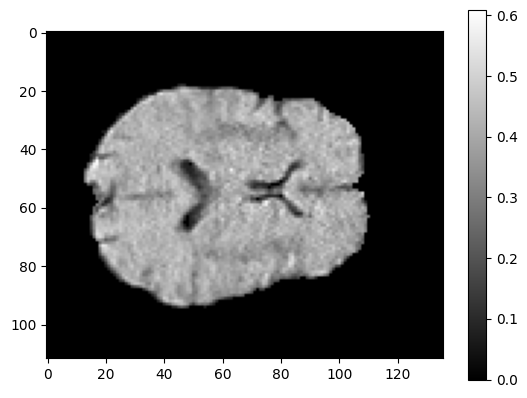

In [3]:
plt.imshow(lf_gt[:,:,slice_num,0], cmap='gray')
plt.colorbar()

Download artifacts

In [4]:
# To download an artifact from wandb

import wandb
# wandb_init = wandb.init()
api = wandb.Api()
run_id = "4qq20v69" #change this every time
entity = "pi58-sussex/"
project = "hulfsynth/"
run = api.run(entity + project + run_id)
logged_artifacts = run.logged_artifacts(10)
# print(logged_artifacts[0].name, logged_artifacts[1].name, logged_artifacts(temp)) #check number of logged artifacts in this list. usually should return two
model_version = logged_artifacts[0].name
print("Model version: ", model_version)
artifact = api.artifact(entity + project +  model_version)
artifact_dir = artifact.download()


Model version:  model:v236


wandb:   1 of 1 files downloaded.  


In [5]:
# model_loc = "./saved_models/model_746.onnx"
model_temp_loc = model_loc = './saved_models/val_data/model_236.onnx'
onnx_model = onnx.load(model_loc)
onnx.checker.check_model(onnx_model)

onnx_model.graph.input[0].type.tensor_type.shape.dim[0].ClearField('dim_value')
onnx_model.graph.input[0].type.tensor_type.shape.dim[1].ClearField('dim_value')
# onnx_model.graph.input[0].type.tensor_type.shape.dim[2].ClearField('dim_value')
# onnx_model.graph.input[0].type.tensor_type.shape.dim[3].ClearField('dim_value')
sess = InferenceSession(onnx_model.SerializeToString())

In [6]:
onnx_model.graph.input[0].type.tensor_type.shape

dim {
}
dim {
}

In [7]:
dummy_input, _ , _ = next(iter(dataloader))
dummy_input = dummy_input.view(-1, dummy_input.shape[-1])
sess.run(None, {"onnx::Gemm_0" : dummy_input.cpu().numpy()})

[array([3.9413571e-04, 7.4668229e-04, 4.6299872e-01, ..., 0.0000000e+00,
        8.1780553e-04, 5.6912750e-04], shape=(36864,), dtype=float32),
 array([ 3.9413571e-04,  7.4668229e-04,  4.6299872e-01, ...,
        -5.5722892e-05,  8.1780553e-04,  5.6912750e-04],
       shape=(36864,), dtype=float32),
 array([[0.9877644 , 0.00408799, 0.00417788, 0.00396981],
        [0.9875079 , 0.00416705, 0.00416765, 0.00415744],
        [0.05522306, 0.85185105, 0.0558215 , 0.03710448],
        ...,
        [0.98751175, 0.00437173, 0.00398203, 0.00413449],
        [0.9872083 , 0.00433959, 0.00421417, 0.00423788],
        [0.9876945 , 0.00402233, 0.00406484, 0.00421839]],
       shape=(36864, 4), dtype=float32),
 array([[-2.5518052e-04, -5.4876456e+00, -5.4658966e+00, -5.5169821e+00],
        [-2.7049705e-04, -5.4682460e+00, -5.4681025e+00, -5.4705553e+00],
        [-2.5542453e-05,  2.7360055e+00,  1.0752991e-02, -3.9766830e-01],
        ...,
        [-2.2695214e-04, -5.4202557e+00, -5.5136247e+00, -5.4

Contrast Modulation

In [33]:
def contrast_modulation(pred_seg, pred_img, config):
    downsampled_points = config["downsampled_points"]
    M = config["M"]
    size_lf = config["size_lf"]
    # pred_seg = torch.from_numpy(pred_seg)
    pred_img = torch.from_numpy(pred_img)
    imgs_list = [(F.interpolate((pred_seg[i] * pred_img).permute(2,0,1).unsqueeze(0), size=size_lf[:2]).squeeze(0).permute(1,2,0)) for i in range(pred_seg.shape[0])]
    bg_img = (imgs_list[0]).reshape(size_lf)
    wm_img = (imgs_list[1]).reshape(size_lf) * M[0]
    gm_img = (imgs_list[2]).reshape(size_lf) * M[1]
    csf_img = (imgs_list[3]).reshape(size_lf) * M[2]

    lf_img = wm_img + gm_img + csf_img + bg_img
    return lf_img

Inference

In [8]:
resolution = hf_ground_truth.shape
device = 'cpu' #get_device()
meshgrid = torch.meshgrid([torch.arange(0, i, device=device) for i in resolution], indexing='ij')
coords = torch.stack(meshgrid, dim=-1)
coords_norm = coords / torch.tensor(resolution, device=device) * 2 - 1
coords_norm_ = coords_norm.reshape(-1, coords.shape[-1])
predictions_, _, pred_seg_, _ = sess.run(None, {"onnx::Gemm_0" : coords_norm_.cpu().numpy()})
predictions = predictions_.reshape(resolution)
resolution_seg = list(resolution) + [pred_seg_.shape[-1]] #adding num_tissues to the resolution shape
pred_seg_ = pred_seg_.reshape(resolution_seg)
pred_seg = [pred_seg_[:,:,:,i].reshape(resolution) for i in range(pred_seg_.shape[-1])]
pred_seg = np.stack(pred_seg, axis = 0)

2025-10-15 07:31:17.952944660 [W:onnxruntime:, execution_frame.cc:874 VerifyOutputSizes] Expected shape from model of {36864,4} does not match actual shape of {609280,4} for output input.3
2025-10-15 07:31:17.953501546 [W:onnxruntime:, execution_frame.cc:874 VerifyOutputSizes] Expected shape from model of {36864,4} does not match actual shape of {609280,4} for output 48
2025-10-15 07:31:17.954190794 [W:onnxruntime:, execution_frame.cc:874 VerifyOutputSizes] Expected shape from model of {36864} does not match actual shape of {609280} for output input
2025-10-15 07:31:17.954579588 [W:onnxruntime:, execution_frame.cc:874 VerifyOutputSizes] Expected shape from model of {36864} does not match actual shape of {609280} for output 47


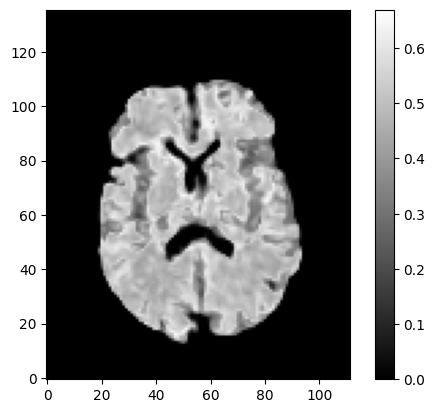

In [9]:
plt.imshow((predictions[:,:,slice_num]).T,cmap='gray')
plt.gca().invert_yaxis()
plt.colorbar()

Visualize segmentations

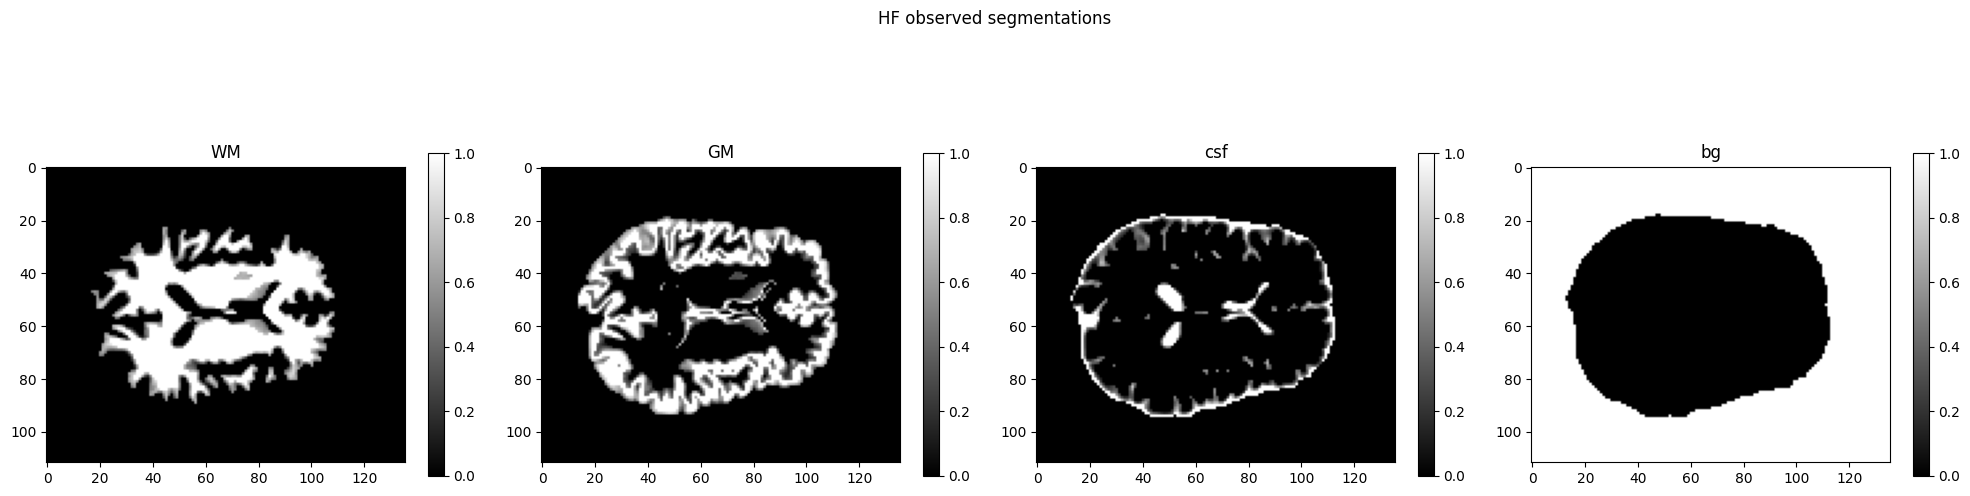

In [10]:
from LFSynth.HF_ContrastEstimation import get_hf_observed, get_hf_observed_segmentations
from Utils.plotting_utils import plot_4_images

folder = './Data/validation_data/sub_' + dataset_num + '/'
(wm_gt_seg, gm_gt_seg, csf_gt_seg, bg_gt_seg) = get_hf_observed_segmentations(dataset_num, config)
images_gt = [bg_gt_seg[:,:,slice_num], wm_gt_seg[:,:,slice_num], gm_gt_seg[:,:,slice_num], csf_gt_seg[:,:,slice_num]]
titles = ['BG', 'WM', 'GM', 'CSF']
fig = plot_4_images(wm_gt_seg[:,:,slice_num], gm_gt_seg[:,:,slice_num], csf_gt_seg[:,:,slice_num], bg_gt_seg[:,:,slice_num], title1="WM", title2="GM", title3="csf", title4="bg")
fig.suptitle('HF observed segmentations')
fig.tight_layout()
plt.show()

In [11]:
def plot_8_images_2rows(images, titles=None, figsize=(16, 8), cmap='gray', suptitle=None, row_labels=None, save_path=None, dpi=100):
    """
    Plot 8 images in 2 rows (4 images per row) using matplotlib.
    
    Parameters:
    -----------
    images : list or array-like
        List of 8 images to plot. Each image should be a numpy array.
        Can be 2D (grayscale) or 3D (RGB/color) arrays.
        Images 0-3 go in first row, images 4-7 go in second row.
    titles : list, optional
        List of 8 titles for each subplot. Default is None.
    figsize : tuple, optional
        Figure size as (width, height). Default is (16, 8).
    cmap : str, optional
        Colormap for grayscale images. Default is 'gray'.
    suptitle : str, optional
        Overall title for the entire figure. Default is None.
    row_labels : list, optional
        List of 2 labels for each row (appears on left side). Default is None.
    save_path : str, optional
        Path to save the figure. If None, figure is not saved.
    dpi : int, optional
        DPI for saved figure. Default is 100.
    
    Returns:
    --------
    fig, axes : matplotlib figure and axes objects (2x4 array)
    
    Example:
    --------
    # With 8 random images
    images = [np.random.rand(100, 100) for _ in range(8)]
    titles = [f'Image {i+1}' for i in range(8)]
    plot_8_images_2rows(images, titles=titles, suptitle='8 Sample Images')
    plt.show()
    """
    
    if len(images) != 8:
        raise ValueError("Exactly 8 images must be provided")
    
    # Create figure and subplots (2 rows, 4 columns)
    fig, axes = plt.subplots(2, 4, figsize=figsize)
    
    # Set overall title if provided
    if suptitle:
        fig.suptitle(suptitle, fontsize=16, fontweight='bold', y=0.98)
    
    # Plot images
    for i, img in enumerate(images):
        row_idx = i // 4  # Row index (0 or 1)
        col_idx = i % 4   # Column index (0, 1, 2, or 3)
        ax = axes[row_idx, col_idx]
        
        # Handle different image formats
        if len(img.shape) == 2:  # Grayscale
            im = ax.imshow(img, cmap=cmap)
        elif len(img.shape) == 3:  # Color
            if img.shape[2] == 1:  # Single channel
                im = ax.imshow(img.squeeze(), cmap=cmap)
            else:  # RGB/RGBA
                im = ax.imshow(img)
        else:
            raise ValueError(f"Image {i} has unsupported shape: {img.shape}")
        
        # Set title if provided
        if titles and i < len(titles):
            ax.set_title(titles[i], fontsize=12, pad=10)
        
        # Remove axes ticks
        ax.set_xticks([])
        ax.set_yticks([])
        
        # Add row labels on the leftmost column
        if col_idx == 0 and row_labels and row_idx < len(row_labels):
            ax.set_ylabel(row_labels[row_idx], fontsize=9, color='blue',
                         rotation=90, labelpad=10)
    
    # Adjust layout
    plt.tight_layout()
    
    # Save figure if path provided
    if save_path:
        plt.savefig(save_path, dpi=dpi, bbox_inches='tight')
        print(f"Figure saved to: {save_path}")
    
    return fig, axes

(<Figure size 1200x600 with 8 Axes>,
 array([[<Axes: title={'center': 'BG'}, ylabel='observed (slice: 11)'>,
         <Axes: title={'center': 'WM'}>, <Axes: title={'center': 'GM'}>,
         <Axes: title={'center': 'CSF'}>],
        [<Axes: ylabel='predicted (slice: 11)'>, <Axes: >, <Axes: >,
         <Axes: >]], dtype=object))

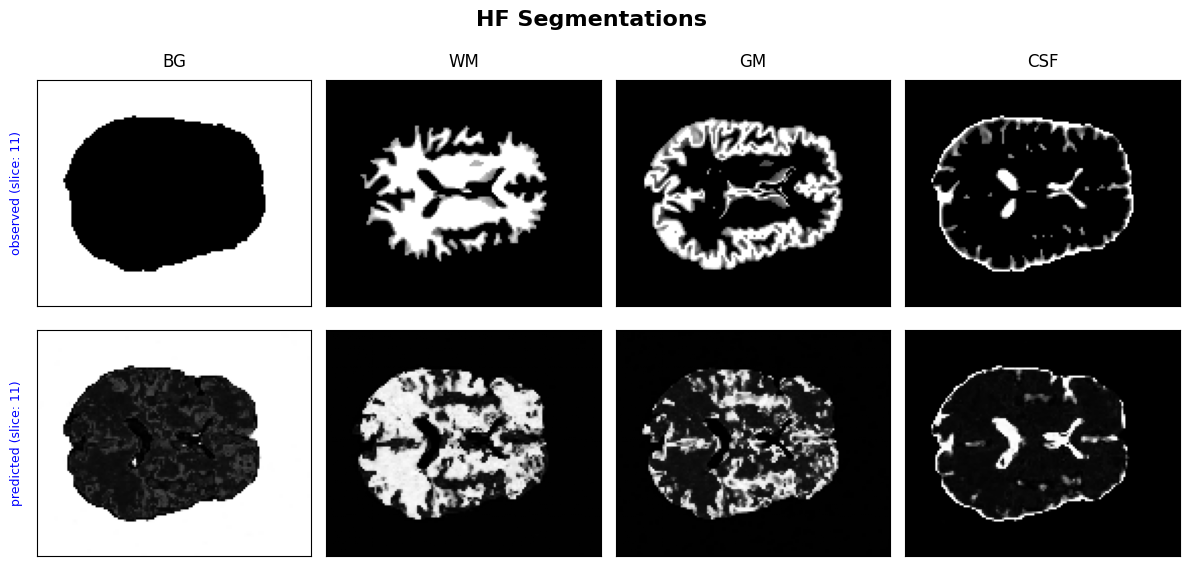

In [12]:
images_gt = [bg_gt_seg[:,:,slice_num], wm_gt_seg[:,:,slice_num], gm_gt_seg[:,:,slice_num], csf_gt_seg[:,:,slice_num]]
titles = ['BG', 'WM', 'GM', 'CSF']
images_pred = [pred_seg[0,:,:,slice_num], pred_seg[1,:,:,slice_num], pred_seg[2,:,:,slice_num], pred_seg[3,:,:,slice_num]]
# titles = ['BG', 'WM', 'GM', 'CSF']
plot_8_images_2rows(images_gt + images_pred, titles=titles, figsize=(12, 6), cmap='gray', suptitle='HF Segmentations ', row_labels=['observed' +' (slice: ' + str(slice_num) +')', 'predicted '+ '(slice: ' + str(slice_num) +')'], save_path=None, dpi=100)

(<Figure size 1200x600 with 8 Axes>,
 array([[<Axes: title={'center': 'BG'}, ylabel='observed (slice: 12)'>,
         <Axes: title={'center': 'WM'}>, <Axes: title={'center': 'GM'}>,
         <Axes: title={'center': 'CSF'}>],
        [<Axes: ylabel='predicted(slice: 12)'>, <Axes: >, <Axes: >,
         <Axes: >]], dtype=object))

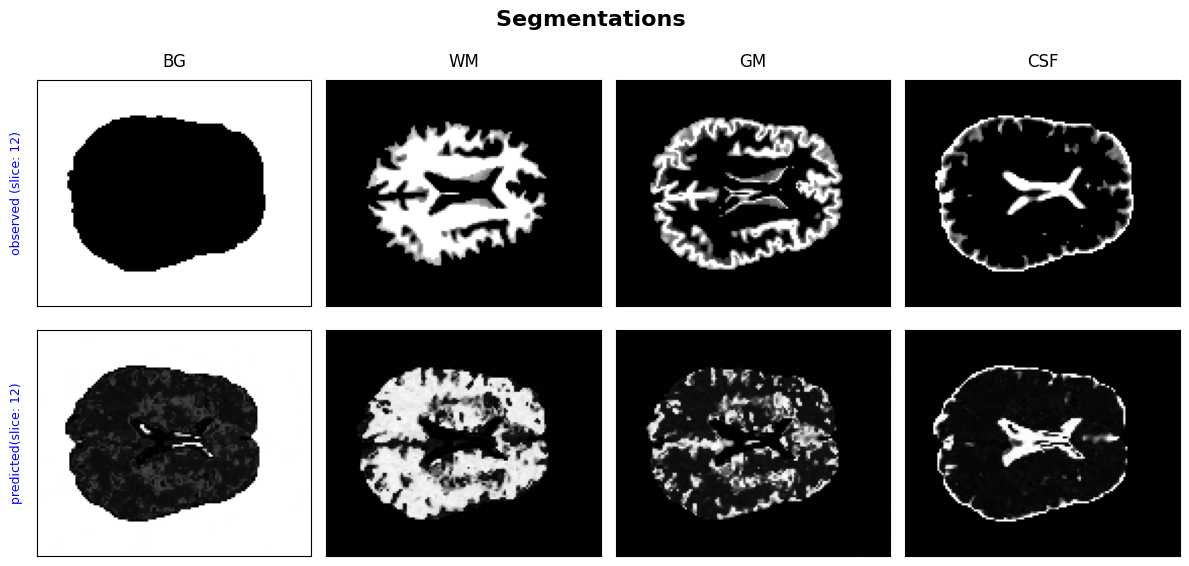

In [13]:
other_slice = slice_num + 1
images_gt = [bg_gt_seg[:,:,other_slice], wm_gt_seg[:,:,other_slice], gm_gt_seg[:,:,other_slice], csf_gt_seg[:,:,other_slice]]
titles = ['BG', 'WM', 'GM', 'CSF']
images_pred = [pred_seg[0,:,:,other_slice], pred_seg[1,:,:,other_slice], pred_seg[2,:,:,other_slice], pred_seg[3,:,:,other_slice]]
# titles = ['BG', 'WM', 'GM', 'CSF']
plot_8_images_2rows(images_gt + images_pred, titles=titles, figsize=(12, 6), cmap='gray', suptitle='Segmentations ', row_labels=['observed' +' (slice: ' + str(other_slice) +')', 'predicted'+ '(slice: ' + str(other_slice) +')'], save_path=None, dpi=100)

(<Figure size 1200x600 with 8 Axes>,
 array([[<Axes: title={'center': 'BG'}, ylabel='observed (slice: 12)'>,
         <Axes: title={'center': 'WM'}>, <Axes: title={'center': 'GM'}>,
         <Axes: title={'center': 'CSF'}>],
        [<Axes: ylabel='predicted(slice: 12)'>, <Axes: >, <Axes: >,
         <Axes: >]], dtype=object))

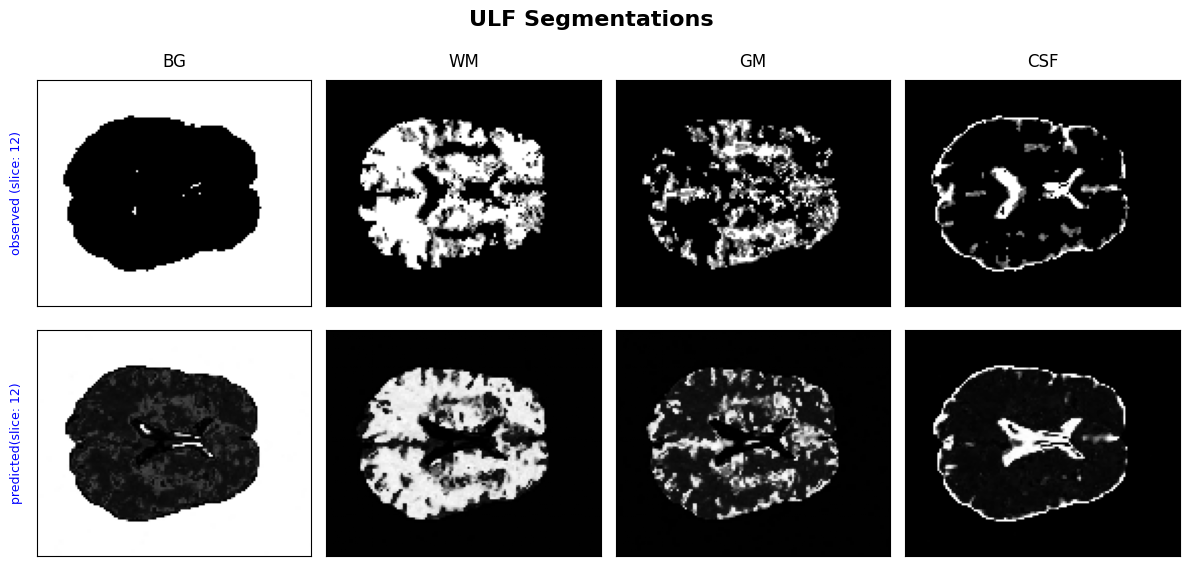

In [27]:
pred_hf_seg = torch.from_numpy(pred_seg)
pred_lf_seg = [(F.interpolate(pred_hf_seg[i].permute(2,0,1).unsqueeze(0), size=lf_gt.shape[:-2]).squeeze(0)).permute(1,2,0).reshape(lf_gt_seg_dice.shape[2:]) for i in range(pred_hf_seg.shape[0])] #downsampling pred_seg
pred_lf_seg = torch.stack(pred_lf_seg,axis = 0) # shape(4 *H_lf, *W_lf, *D)



images_gt = [lf_gt_seg_dice[0,0,:,:,slice_num], lf_gt_seg_dice[0,1,:,:,slice_num], lf_gt_seg_dice[0,2,:,:,slice_num], lf_gt_seg_dice[0,3,:,:,slice_num] ]
titles = ['BG', 'WM', 'GM', 'CSF']
images_pred = [pred_lf_seg[0,:,:,other_slice], pred_lf_seg[1,:,:,other_slice], pred_lf_seg[2,:,:,other_slice], pred_lf_seg[3,:,:,other_slice]]
# titles = ['BG', 'WM', 'GM', 'CSF']
plot_8_images_2rows(images_gt + images_pred, titles=titles, figsize=(12, 6), cmap='gray', suptitle='ULF Segmentations ', row_labels=['observed' +' (slice: ' + str(other_slice) +')', 'predicted'+ '(slice: ' + str(other_slice) +')'], save_path=None, dpi=100)

In [14]:
def plot_3_images_row(images, titles=None, figsize=(12, 4), cmap='gray',  suptitle=None, save_path=None, dpi=100, show_colorbar=False):
    """
    Plot 3 images in a single row using matplotlib.
    
    Parameters:
    -----------
    images : list or array-like
        List of 3 images to plot. Each image should be a numpy array.
        Can be 2D (grayscale) or 3D (RGB/color) arrays.
    titles : list, optional
        List of 3 titles for each subplot. Default is None.
    figsize : tuple, optional
        Figure size as (width, height). Default is (12, 4).
    cmap : str, optional
        Colormap for grayscale images. Default is 'gray'.
    suptitle : str, optional
        Overall title for the entire figure. Default is None.
    save_path : str, optional
        Path to save the figure. If None, figure is not saved.
    dpi : int, optional
        DPI for saved figure. Default is 100.
    show_colorbar : bool, optional
        Whether to show colorbar for grayscale images. Default is False.
    
    Returns:
    --------
    fig, axes : matplotlib figure and axes objects
    
    Example:
    --------
    # With random images
    images = [np.random.rand(100, 100) for _ in range(3)]
    titles = ['Original', 'Processed', 'Result']
    plot_3_images_row(images, titles=titles, suptitle='Image Processing Pipeline')
    plt.show()
    """
    
    if len(images) != 3:
        raise ValueError("Exactly 3 images must be provided")
    
    # Create figure and subplots
    fig, axes = plt.subplots(1, 3, figsize=figsize)
    
    # Set overall title if provided
    if suptitle:
        fig.suptitle(suptitle, fontsize=16, fontweight='bold', y=1.02)
    
    # Plot each image
    for i, (ax, img) in enumerate(zip(axes, images)):
        # Handle different image formats
        if len(img.shape) == 2:  # Grayscale
            im = ax.imshow(img, cmap=cmap)
            if show_colorbar:
                plt.colorbar(im, ax=ax, shrink=0.8)
        elif len(img.shape) == 3:  # Color
            if img.shape[2] == 1:  # Single channel
                im = ax.imshow(img.squeeze(), cmap=cmap)
                if show_colorbar:
                    plt.colorbar(im, ax=ax, shrink=0.8)
            else:  # RGB/RGBA
                im = ax.imshow(img)
        else:
            raise ValueError(f"Image {i} has unsupported shape: {img.shape}")
        
        # Set title if provided
        if titles and i < len(titles):
            ax.set_title(titles[i], fontsize=12, pad=10, color = 'blue')
        
        # Remove axes ticks
        ax.set_xticks([])
        ax.set_yticks([])
    
    # Adjust layout
    plt.tight_layout()
    
    # Save figure if path provided
    if save_path:
        plt.savefig(save_path, dpi=dpi, bbox_inches='tight')
        print(f"Figure saved to: {save_path}")
    
    return fig, axes

(<Figure size 1200x400 with 6 Axes>,
 array([<Axes: title={'center': 'observed'}>,
        <Axes: title={'center': 'predicted'}>,
        <Axes: title={'center': 'predicted (weighted sum)'}>], dtype=object))

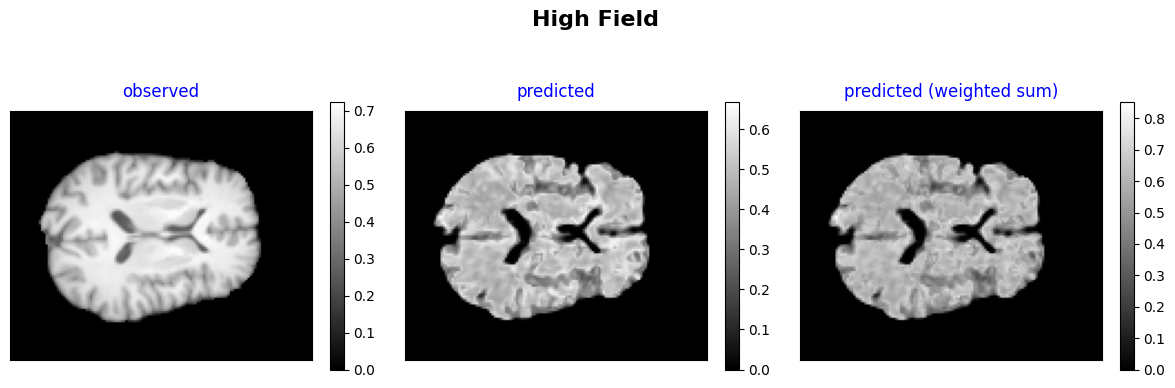

In [28]:
final_img = (predictions * pred_seg[1]) + (predictions * pred_seg[2]) + (predictions * pred_seg[3]) #+ (predictions * pred_seg[0])
# plt.imshow(final_img[:,:,95], cmap='gray')

images = [norm(torch.from_numpy(hf_ground_truth))[:,:,slice_num] , (predictions)[:,:,slice_num], norm(final_img)[:,:,slice_num]]
# images2 = [norm(predictions * pred_seg[0])[:,:,slice_num] , norm((predictions * pred_seg[2]))[:,:,slice_num], norm((predictions * pred_seg[3]))[:,:,slice_num]]
titles = ['observed', 'predicted', 'predicted (weighted sum)']
plot_3_images_row(images, titles=titles, figsize=(12, 4), cmap='gray',  suptitle='High Field', save_path=None, dpi=100, show_colorbar=True)

Metrics

In [55]:
dice_score = monai.metrics.DiceMetric()
dice2 = monai.metrics.GeneralizedDiceScore()
iou_score = monai.metrics.MeanIoU()
psnr_value = monai.metrics.PSNRMetric(max_val = 1.0) #expects shape: BCHWD
ssim_value = monai.metrics.regression.SSIMMetric(spatial_dims=3, data_range=1.0) #expects shape: BCHWD

hf_gt_seg = torch.from_numpy(np.stack((bg_gt_seg, wm_gt_seg, gm_gt_seg, csf_gt_seg), axis = 0))


print("Dice (mean): ", dice_score(torch.from_numpy(pred_seg).unsqueeze(0), (hf_gt_seg).unsqueeze(0)).mean())
print("Dice (generalized): ", dice2(torch.from_numpy(pred_seg).unsqueeze(0), (hf_gt_seg).unsqueeze(0).to(torch.float32)).mean())
print("IoU (mean): ", iou_score(torch.from_numpy(pred_seg).unsqueeze(0), (hf_gt_seg).unsqueeze(0)).mean())
print('psnr: ', psnr_value( torch.from_numpy(predictions).unsqueeze(0).unsqueeze(0), norm(torch.from_numpy(hf_ground_truth)).unsqueeze(0).unsqueeze(0)))
print('ssim: ', ssim_value( torch.from_numpy(predictions).unsqueeze(0).unsqueeze(0), norm(torch.from_numpy(hf_ground_truth)).unsqueeze(0).unsqueeze(0)))

Dice (mean):  tensor(0.3078, dtype=torch.float64)
Dice (generalized):  tensor(0.4542)
IoU (mean):  tensor(0.4523, dtype=torch.float64)
psnr:  tensor([[19.8030]], dtype=torch.float64)
ssim:  tensor([[0.8382]])


In [56]:
final_img = (predictions * pred_seg[1]) + (predictions * pred_seg[2]) + (predictions * pred_seg[3]) #+ (predictions * pred_seg[0])
print('psnr: ', psnr_value( torch.from_numpy(final_img).unsqueeze(0).unsqueeze(0), norm(torch.from_numpy(hf_ground_truth)).unsqueeze(0).unsqueeze(0)))
print('ssim: ', ssim_value( torch.from_numpy(final_img).unsqueeze(0).unsqueeze(0), norm(torch.from_numpy(hf_ground_truth)).unsqueeze(0).unsqueeze(0)))

psnr:  tensor([[19.2769]], dtype=torch.float64)
ssim:  tensor([[0.8406]])


(<Figure size 1200x400 with 6 Axes>,
 array([<Axes: title={'center': 'observed'}>,
        <Axes: title={'center': 'predicted'}>,
        <Axes: title={'center': 'predicted (weighted sum)'}>], dtype=object))

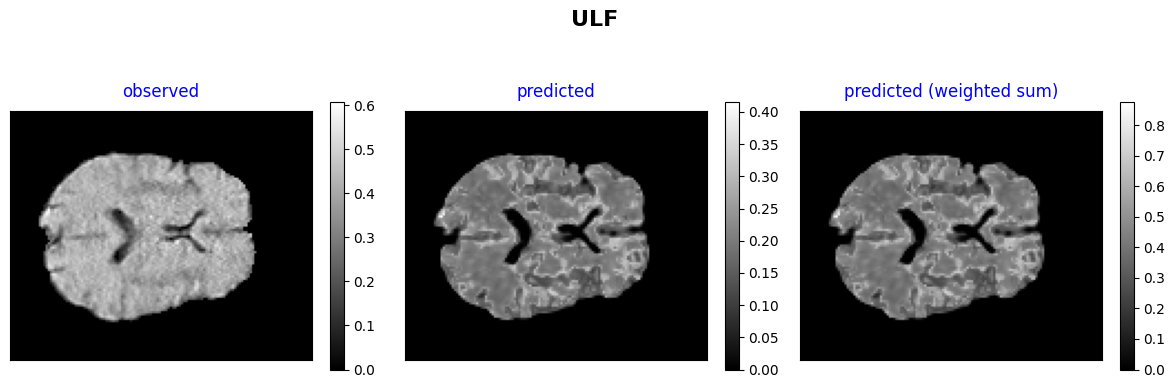

In [54]:
pred_ulf1 = contrast_modulation(pred_hf_seg, final_img, config) #try with pred_img, norm_pred
pred_ulf2 = contrast_modulation(pred_hf_seg, predictions, config) #try with pred_img, norm_pred
pred_ulf1.shape, pred_ulf2.shape




images = [lf_gt[:,:,slice_num,0], pred_ulf1[:,:,slice_num], norm(pred_ulf2)[:,:,slice_num]]
# images2 = [norm(predictions * pred_seg[0])[:,:,slice_num] , norm((predictions * pred_seg[2]))[:,:,slice_num], norm((predictions * pred_seg[3]))[:,:,slice_num]]
titles = ['observed', 'predicted', 'predicted (weighted sum)']
plot_3_images_row(images, titles=titles, figsize=(12, 4), cmap='gray',  suptitle='ULF', save_path=None, dpi=100, show_colorbar=True)


Final Image (multiple views)

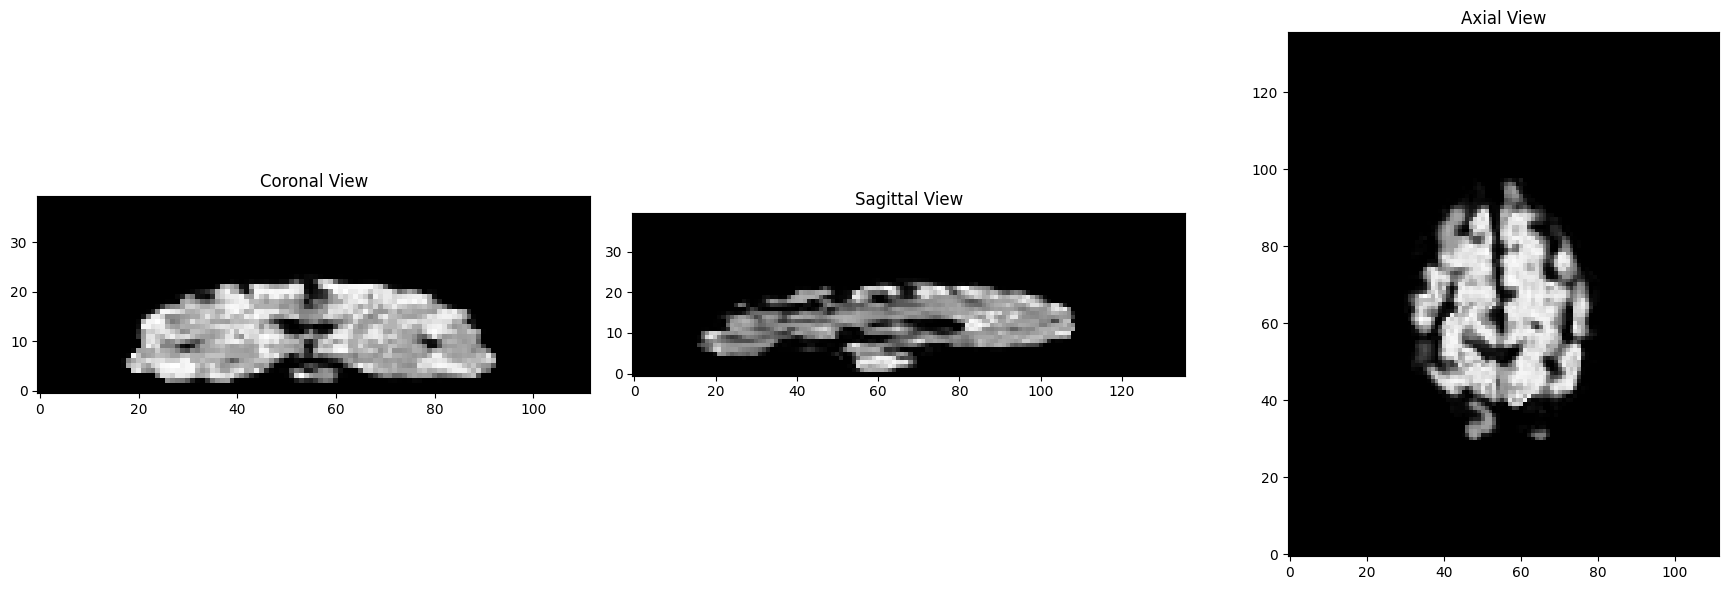

In [21]:
# Create a figure with three subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
# data = gt_image[:,:,:,0]
# data = lf_gt_seg_dice[0,1,:,:,].detach().cpu()
data = final_img
dims = data.shape
# Coronal slice
coronal_slice_index = dims[1] // 2
coronal_slice = data[:, coronal_slice_index, :].T
axes[0].imshow(coronal_slice, cmap='gray')
axes[0].set_title("Coronal View")

axes[0].set_aspect('equal')
axes[0].invert_yaxis()

# Sagittal slice
sagittal_slice_index = dims[0] // 2
sagittal_slice = data[sagittal_slice_index, :, :].T
axes[1].imshow(sagittal_slice, cmap='gray')
axes[1].set_title("Sagittal View")

axes[1].set_aspect('equal')
axes[1].invert_yaxis()

# Axial slice
axial_slice_index = dims[2] // 2
axial_slice = data[:, :, axial_slice_index].T
axes[2].imshow(axial_slice, cmap='gray')
axes[2].set_title("Axial View")

axes[2].set_aspect('equal')
axes[2].invert_yaxis()

plt.tight_layout()

plt.show()

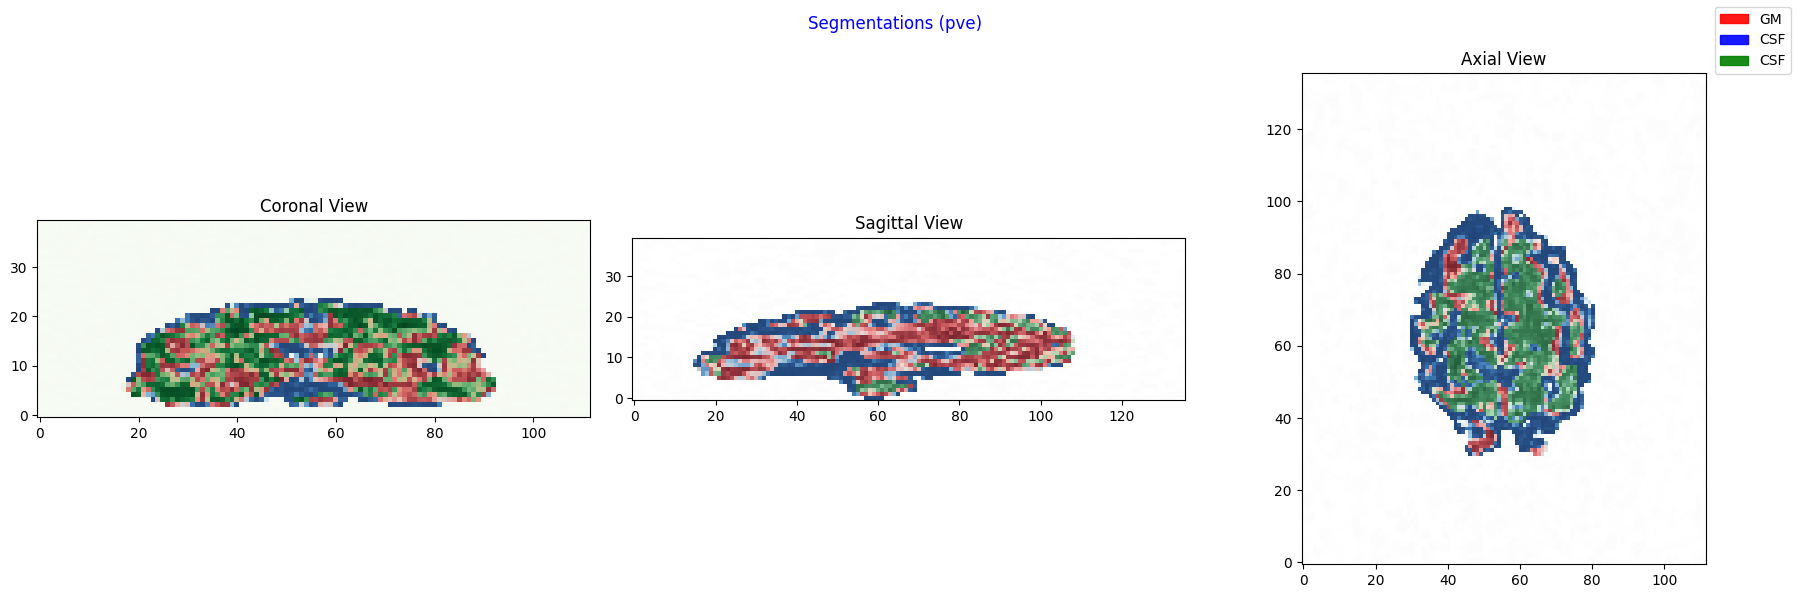

In [22]:
import matplotlib.patches as mpatches

# Create a figure with three subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
# data = gt_image[:,:,:,0]
# data = lf_gt_seg_dice[0,1,:,:,].detach().cpu()
data1 = pred_seg[1]
data2 = pred_seg[2]
data3 = pred_seg[3]
dims = data1.shape
# Coronal slice
coronal_slice_index = dims[1] // 2
coronal_slice1 = data1[:, coronal_slice_index, :].T
coronal_slice2 = data2[:, coronal_slice_index, :].T
coronal_slice3 = data3[:, coronal_slice_index, :].T




axes[0].imshow(coronal_slice1, cmap='Greens')
axes[0].imshow(coronal_slice2, cmap='Reds', alpha = 0.9 * coronal_slice2)
axes[0].imshow(coronal_slice3, cmap='Blues', alpha = 0.9 * coronal_slice3)
axes[0].set_title("Coronal View")

axes[0].set_aspect('equal')
axes[0].invert_yaxis()

# Sagittal slice
sagittal_slice_index = dims[0] // 2
sagittal_slice1 = data1[sagittal_slice_index, :, :].T
sagittal_slice2 = data2[sagittal_slice_index, :, :].T
sagittal_slice3 = data3[sagittal_slice_index, :, :].T
axes[1].imshow(sagittal_slice1, cmap='Greens', alpha = 0.9 * sagittal_slice1)
axes[1].imshow(sagittal_slice2, cmap='Reds', alpha = 0.9 * sagittal_slice2)
axes[1].imshow(sagittal_slice3, cmap='Blues', alpha = 0.9 * sagittal_slice3)
axes[1].set_title("Sagittal View")

axes[1].set_aspect('equal')
axes[1].invert_yaxis()

# Axial slice
axial_slice_index = dims[2] // 2
axial_slice1 = data1[:, :, axial_slice_index].T
axial_slice2 = data2[:, :, axial_slice_index].T
axial_slice3 = data3[:, :, axial_slice_index].T

axes[2].imshow(axial_slice1, cmap='Greens', alpha = 0.9 * axial_slice1)
axes[2].imshow(axial_slice2, cmap='Reds', alpha = 0.9 * axial_slice2)
axes[2].imshow(axial_slice3, cmap='Blues', alpha = 0.9 * axial_slice3)
axes[2].set_title("Axial View")

axes[2].set_aspect('equal')
axes[2].invert_yaxis()


fig.suptitle("Segmentations (pve)", color='blue')
green_patch = mpatches.Patch(color='green', alpha=0.9, label='CSF')
red_patch = mpatches.Patch(color='red', alpha=0.9, label='GM')
blue_patch = mpatches.Patch(color='blue', alpha=0.9, label='CSF')

fig.legend(handles=[red_patch, blue_patch, green_patch])#, loc='lower right')
# fig.legend(handles=[red_patch, blue_patch], loc='center', fontsize=12)


plt.tight_layout()
plt.show()